In [10]:
# =========================================================
# CELDA 0) Instalación + imports + descarga desde GitHub + carga + diagnóstico
# Repo: https://github.com/AlfonsoMoralesD/GEOMARKETING_2025-2/tree/main/Data
# =========================================================

!pip -q install geopandas osmnx rapidfuzz openpyxl xlrd

import os
from pathlib import Path
from urllib.parse import quote

import requests
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import osmnx as ox
import networkx as nx
from shapely.geometry import Point
from rapidfuzz import fuzz, process

pd.set_option("display.max_columns", 200)

# -----------------------------
# 1) Descargar archivos desde GitHub (raw)
# -----------------------------
OUT_DIR = Path("/content/Data")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = [
    "Colegios.geojson",
    "Tabla_colegios.xls",
    "shp_ñuñoa.cpg",
    "shp_ñuñoa.dbf",
    "shp_ñuñoa.prj",
    "shp_ñuñoa.sbn",
    "shp_ñuñoa.sbx",
    "shp_ñuñoa.shp",
    "shp_ñuñoa.shx",
]

def download_all(branch="main"):
    base_raw = f"https://raw.githubusercontent.com/AlfonsoMoralesD/GEOMARKETING_2025-2/{branch}/Data/"
    for fname in FILES:
        url = base_raw + quote(fname)  # importante para la ñ
        out_path = OUT_DIR / fname

        r = requests.get(url, timeout=60)
        if r.status_code != 200:
            raise RuntimeError(f" No se pudo descargar {fname} (HTTP {r.status_code}). URL: {url}")

        out_path.write_bytes(r.content)

        # Chequeo básico de tamaño
        if out_path.stat().st_size < 50:
            print(f"  {fname} quedó muy chico ({out_path.stat().st_size} bytes). Revisa el URL.")
        else:
            print(f" {fname} OK ({out_path.stat().st_size/1024:.1f} KB)")

# Intentar main, si falla probar master
try:
    print(" Descargando desde branch: main")
    download_all("main")
except Exception as e:
    print(" Falló con 'main'. Probando con 'master'...")
    # limpiar lo descargado parcial para evitar mezclas
    for p in OUT_DIR.glob("*"):
        try: p.unlink()
        except: pass
    print(" Descargando desde branch: master")
    download_all("master")

print("\n Archivos en /content/Data:")
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.name)

 Descargando desde branch: main
 Colegios.geojson OK (102.7 KB)
 Tabla_colegios.xls OK (74.0 KB)
  shp_ñuñoa.cpg quedó muy chico (5 bytes). Revisa el URL.
 shp_ñuñoa.dbf OK (1596.1 KB)
 shp_ñuñoa.prj OK (0.1 KB)
 shp_ñuñoa.sbn OK (13.9 KB)
 shp_ñuñoa.sbx OK (1.5 KB)
 shp_ñuñoa.shp OK (753.7 KB)
 shp_ñuñoa.shx OK (10.6 KB)

 Archivos en /content/Data:
 - Colegios.geojson
 - Tabla_colegios.xls
 - shp_ñuñoa.cpg
 - shp_ñuñoa.dbf
 - shp_ñuñoa.prj
 - shp_ñuñoa.sbn
 - shp_ñuñoa.sbx
 - shp_ñuñoa.shp
 - shp_ñuñoa.shx


Zonas: 1347 | OSM: 189 | Tabla: 59
CRS zonas: EPSG:4674
CRS OSM: EPSG:4326
Columnas tabla: ['OID', 'Join_Count', 'TARGET_FID', 'AGNO', 'RBD', 'DGV_RBD', 'NOM_RBD', 'TIPO_SOST', 'COD_REG_RB', 'NOM_REG_RB', 'COD_PRO_RB', 'COD_COM_RB', 'NOM_COM_RB', 'COD_DEPROV', 'NOM_DEPROV', 'TIPO_DEPEN', 'DIRECCION', 'NUMERO', 'REFERENCIA', 'LATITUD']


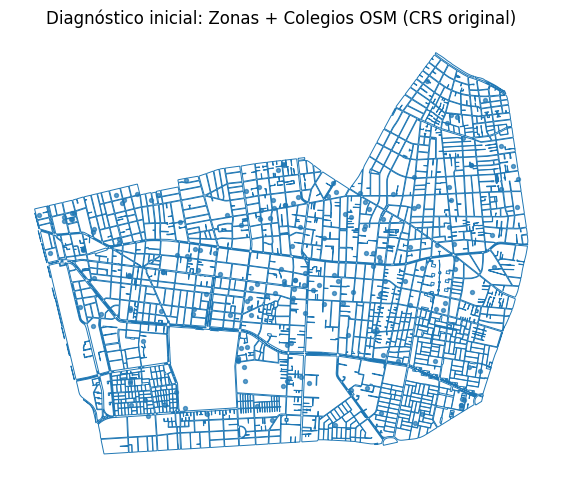

In [6]:
# =========================================================
# CELDA 1) Cargar datos (ajusta nombres si cambian)
#  - shp_ñuñoa.shp + archivos auxiliares (dbf, shx, prj...)
#  - Colegios.geojson (OSM)
#  - Tabla_colegios.xls (lista de nombres a filtrar)
# =========================================================
zonas = gpd.read_file(OUT_DIR / "shp_ñuñoa.shp")
colegios_osm = gpd.read_file(OUT_DIR / "Colegios.geojson")

# .xls suele requerir xlrd (instalado en Celda 0)
tabla = pd.read_excel(OUT_DIR / "Tabla_colegios.xls", engine="xlrd")

print("Zonas:", len(zonas), "| OSM:", len(colegios_osm), "| Tabla:", len(tabla))
print("CRS zonas:", zonas.crs)
print("CRS OSM:", colegios_osm.crs)
print("Columnas tabla:", list(tabla.columns)[:20])

# --- Visualización rápida (en CRS original, solo diagnóstico) ---
fig, ax = plt.subplots(1, 1, figsize=(7,7))
zonas.boundary.plot(ax=ax, linewidth=0.7)
colegios_osm.plot(ax=ax, markersize=8, alpha=0.7)
ax.set_title("Diagnóstico inicial: Zonas + Colegios OSM (CRS original)")
ax.set_axis_off()
plt.show()


CRS zonas: EPSG:32719 | CRS OSM: EPSG:32719


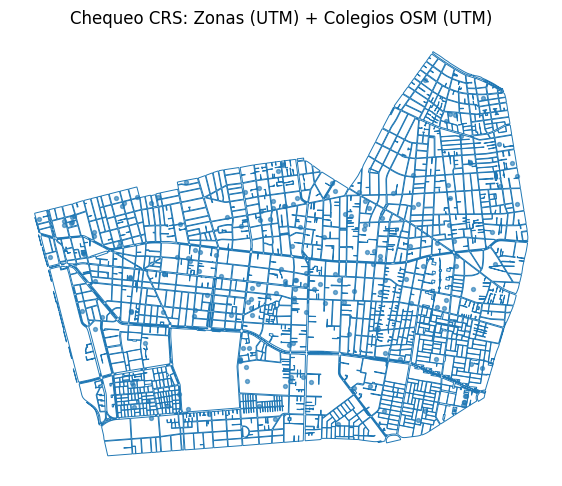

In [7]:
# =========================================================
# CELDA 2) CRS a UTM 19S + IDs
# =========================================================
EPSG_UTM = 32719

zonas = zonas.to_crs(EPSG_UTM).reset_index(drop=True).copy()
zonas["zona_id"] = zonas.index

if colegios_osm.crs is None:
    # si no tiene CRS, normalmente geojson viene en 4326
    colegios_osm = colegios_osm.set_crs(4326)

colegios_osm = colegios_osm.to_crs(EPSG_UTM)

print("CRS zonas:", zonas.crs, "| CRS OSM:", colegios_osm.crs)

# --- Visualización (ya en metros) ---
fig, ax = plt.subplots(1, 1, figsize=(7,7))
zonas.boundary.plot(ax=ax, linewidth=0.7)
colegios_osm.plot(ax=ax, markersize=8, alpha=0.6)
ax.set_title("Chequeo CRS: Zonas (UTM) + Colegios OSM (UTM)")
ax.set_axis_off()
plt.show()


Total tabla: 59
Colegios OSM total: 189
Colegios filtrados (únicos): 77


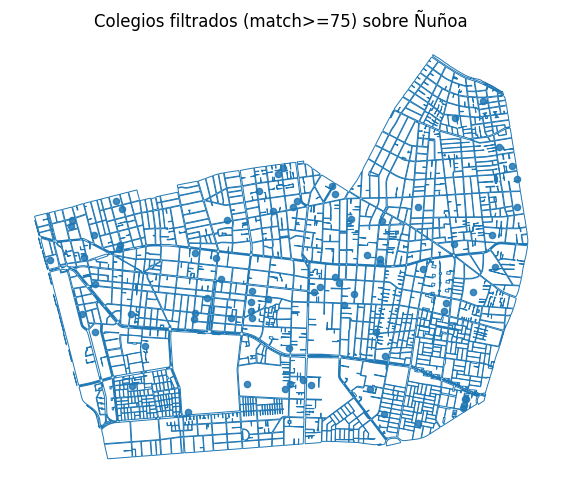

In [8]:
# =========================================================
# CELDA 3) Filtrado por nombres usando variantes OSM
#   -> colegios_f (filtrados únicos)
# =========================================================
def norm_name(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    # quitar tildes básicas
    rep = str.maketrans({"á":"a","é":"e","í":"i","ó":"o","ú":"u","ñ":"n"})
    s = s.translate(rep)
    # limpiar
    s = "".join(c for c in s if c.isalnum() or c.isspace())
    s = " ".join(s.split())
    return s

# columna de nombre en tabla
name_tab = "Nombre_EE" if "Nombre_EE" in tabla.columns else tabla.columns[0]
tabla["name_norm"] = tabla[name_tab].map(norm_name)
tabla_names = tabla["name_norm"].dropna().tolist()
tabla_names = [t for t in tabla_names if t != ""]

# columnas nombre OSM
use_cols = [c for c in ["name", "alt_name", "old_name", "short_name", "name:es", "name:de"] if c in colegios_osm.columns]
if len(use_cols) == 0:
    # fallback: cualquier columna que contenga "name"
    use_cols = [c for c in colegios_osm.columns if "name" in c.lower()]
if len(use_cols) == 0:
    raise ValueError("No encontré columnas de nombre en Colegios.geojson")

# construir variantes por fila (deduplicadas)
rows = []
for idx, row in colegios_osm.iterrows():
    variants = []
    for c in use_cols:
        val = row.get(c, None)
        if pd.isna(val) or val is None:
            continue
        variants.append(norm_name(val))
    variants = list({v for v in variants if v})
    if len(variants) == 0:
        continue
    for v in variants:
        rows.append((idx, v))

variants_df = pd.DataFrame(rows, columns=["osm_idx", "name_norm"])

# fuzzy match: para cada variante, buscar mejor match en tabla
def best_match_score(v):
    if not v:
        return 0
    m = process.extractOne(v, tabla_names, scorer=fuzz.token_set_ratio)
    return m[1] if m else 0

variants_df["score"] = variants_df["name_norm"].map(best_match_score)

thr = 75
good = variants_df[variants_df["score"] >= thr].copy()
matched_osm_idx = good["osm_idx"].unique()

colegios_f = colegios_osm.loc[matched_osm_idx].copy()

print("Total tabla:", len(tabla_names))
print("Colegios OSM total:", len(colegios_osm))
print("Colegios filtrados (únicos):", len(colegios_f))

# parámetros (puedes ajustar)
colegios_f["minutos"] = 15
colegios_f["peso"] = 1.0

# --- Visualización: zonas + colegios filtrados ---
fig, ax = plt.subplots(1, 1, figsize=(7,7))
zonas.boundary.plot(ax=ax, linewidth=0.7)
colegios_f.plot(ax=ax, markersize=20, alpha=0.85)
ax.set_title("Colegios filtrados (match>=75) sobre Ñuñoa")
ax.set_axis_off()
plt.show()


/tmp/ipython-input-1209066832.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  comuna_poly = zonas.unary_union


G listo | nodos: 9962 | aristas: 27620


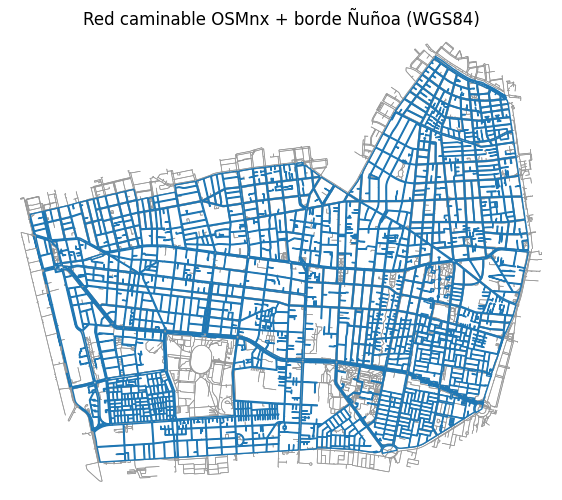

In [9]:
# =========================================================
# CELDA 4) Descargar red caminable + travel_time
# =========================================================
# Polígono comuna en WGS84 para OSMnx
comuna_poly = zonas.unary_union
comuna_wgs = gpd.GeoSeries([comuna_poly], crs=EPSG_UTM).to_crs(4326).iloc[0]

# (pequeño buffer en grados para evitar cortes en borde)
comuna_wgs_buf = comuna_wgs.buffer(0.002)

G = ox.graph_from_polygon(comuna_wgs_buf, network_type="walk", simplify=True)

# tiempos caminata
ox.settings.default_speed_walk = 5
for u, v, k, data in G.edges(keys=True, data=True):
    data["speed_kph"] = 5
G = ox.add_edge_travel_times(G)

print("G listo | nodos:", len(G.nodes), "| aristas:", len(G.edges))

# --- Visualización de red + borde Ñuñoa ---
fig, ax = plt.subplots(1, 1, figsize=(7,7))
zonas.boundary.to_crs(4326).plot(ax=ax, linewidth=1.0)
ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.5, show=False, close=False)
ax.set_title("Red caminable OSMnx + borde Ñuñoa (WGS84)")
ax.set_axis_off()
plt.show()


/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.co

iso_gdf creado: 77


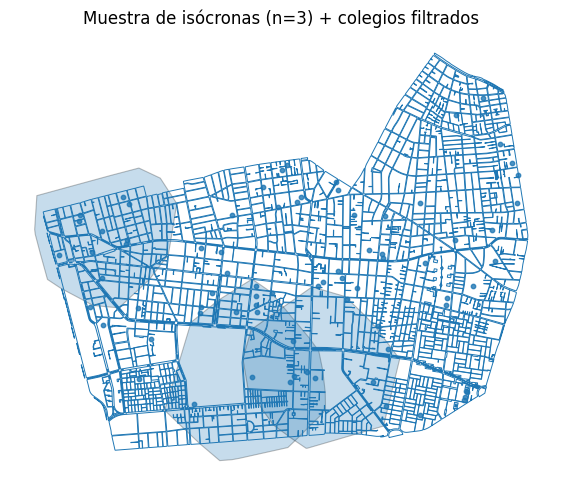

In [ ]:
# =========================================================
# CELDA 5) Función isócrona + crear iso_gdf (oferta actual)
# =========================================================
def make_isochrone(G, point_utm, minutes):
    # punto a WGS84 para nearest node
    p_wgs = gpd.GeoSeries([point_utm], crs=EPSG_UTM).to_crs(4326).iloc[0]
    center = ox.nearest_nodes(G, X=p_wgs.x, Y=p_wgs.y)

    cutoff = minutes * 60
    sub = nx.ego_graph(G, center, radius=cutoff, distance="travel_time")

    node_pts = [Point((data["x"], data["y"])) for n, data in sub.nodes(data=True)]
    if len(node_pts) < 3:
        # fallback pequeño
        return point_utm.buffer(120)

    poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
    return gpd.GeoSeries([poly], crs=4326).to_crs(EPSG_UTM).iloc[0]

iso_rows = []
for idx, row in colegios_f.iterrows():
    iso = make_isochrone(G, row.geometry, int(row["minutos"]))
    iso_rows.append({"id_est": idx, "peso": float(row["peso"]), "geometry": iso})

iso_gdf = gpd.GeoDataFrame(iso_rows, crs=EPSG_UTM)
print("iso_gdf creado:", len(iso_gdf))

# --- Visualización: muestra 3 isócronas ---
m = min(3, len(iso_gdf))
sample_iso = iso_gdf.sample(m, random_state=1) if m > 0 else iso_gdf

fig, ax = plt.subplots(1, 1, figsize=(7,7))
zonas.boundary.plot(ax=ax, linewidth=0.7)
sample_iso.plot(ax=ax, alpha=0.25, edgecolor="black", linewidth=0.8)
colegios_f.plot(ax=ax, markersize=10, alpha=0.8)
ax.set_title(f"Muestra de isócronas (n={m}) + colegios filtrados")
ax.set_axis_off()
plt.show()


Cobertura lista ✅
          oferta_n     SUM_Peso
count  1347.000000  1347.000000
mean     11.850780    11.850780
std       5.826555     5.826555
min       1.000000     1.000000
25%       7.000000     7.000000
50%      11.000000    11.000000
75%      16.000000    16.000000
max      30.000000    30.000000


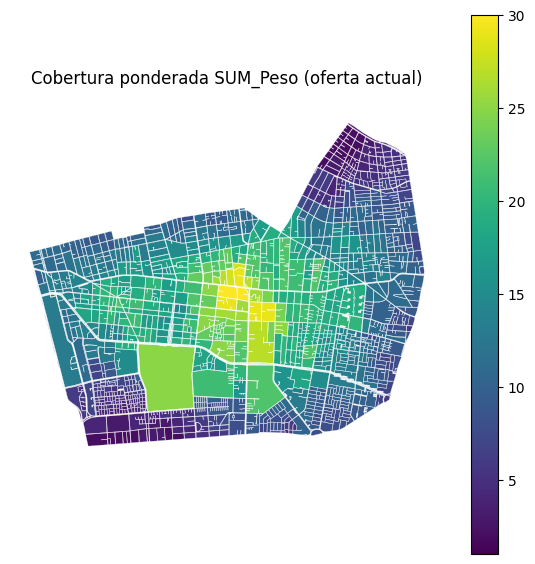

In [ ]:
# =========================================================
# CELDA 6) Cobertura por zona: SUM_Peso + oferta_n
# =========================================================
join = gpd.sjoin(
    zonas[["zona_id", "geometry"]],
    iso_gdf[["id_est", "peso", "geometry"]],
    predicate="intersects",
    how="left"
)

agg = (join.groupby("zona_id")
          .agg(
              oferta_n=("id_est", lambda x: int(x.notna().sum())),
              SUM_Peso=("peso", "sum")
          )
          .reset_index()
      )

zonas = zonas.merge(agg, on="zona_id", how="left")
zonas["oferta_n"] = zonas["oferta_n"].fillna(0).astype(int)
zonas["SUM_Peso"] = zonas["SUM_Peso"].fillna(0.0).astype(float)

print("Cobertura lista ✅")
print(zonas[["oferta_n","SUM_Peso"]].describe())

# --- Visualización SUM_Peso ---
fig, ax = plt.subplots(1, 1, figsize=(7,7))
zonas.plot(column="SUM_Peso", legend=True, ax=ax, linewidth=0.2, edgecolor="white")
ax.set_title("Cobertura ponderada SUM_Peso (oferta actual)")
ax.set_axis_off()
plt.show()


⚠️ No existe demanda_total. Crearé un proxy automáticamente.
✅ demanda_total creada | Fuente: hogares/viviendas | Columna: VIV_COLECT
count    1347.000000
mean        0.100223
std         0.400102
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.000000
Name: demanda_total, dtype: float64


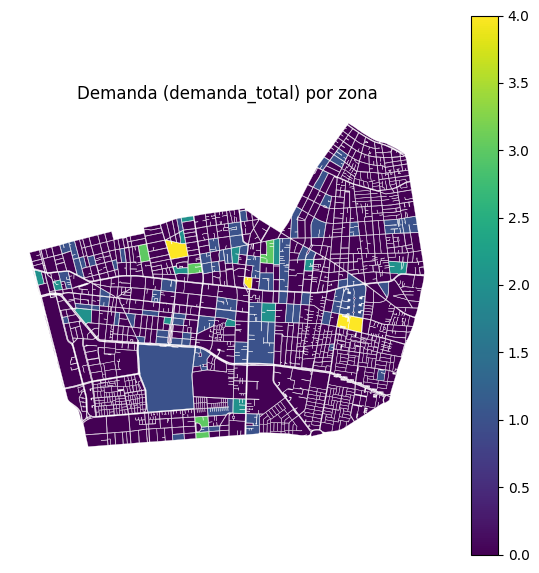

In [ ]:
# =========================================================
# CELDA 7) Demanda: crear demanda_total automáticamente (si no existe)
#  (esto evita tu error: No encuentro 'demanda_total')
# =========================================================
if "demanda_total" not in zonas.columns:
    print("⚠️ No existe demanda_total. Crearé un proxy automáticamente.")

    cand_pop  = [c for c in zonas.columns if any(k in c.lower() for k in ["pob","pop","pobl","habit","person","hab"])]
    cand_hog  = [c for c in zonas.columns if any(k in c.lower() for k in ["hog","house","viv","vivi","home"])]
    cand_ing  = [c for c in zonas.columns if any(k in c.lower() for k in ["ing","income","renta","mediana","median"])]
    cand_den  = [c for c in zonas.columns if "dens" in c.lower()]
    cand_area = [c for c in zonas.columns if any(k in c.lower() for k in ["area","shape_area"])]

    chosen, source = None, None
    if len(cand_pop)>0:  chosen, source = cand_pop[0], "población/habitantes"
    elif len(cand_hog)>0: chosen, source = cand_hog[0], "hogares/viviendas"
    elif len(cand_ing)>0: chosen, source = cand_ing[0], "ingreso/mediana"
    elif len(cand_den)>0: chosen, source = cand_den[0], "densidad"
    elif len(cand_area)>0: chosen, source = cand_area[0], "área"
    else:
        chosen, source = None, "uniforme"

    if chosen is not None:
        zonas["demanda_total"] = pd.to_numeric(zonas[chosen], errors="coerce")
        zonas["demanda_total"] = zonas["demanda_total"].fillna(zonas["demanda_total"].median())
        zonas["demanda_total"] = zonas["demanda_total"].clip(lower=0)
        if float(zonas["demanda_total"].sum()) == 0:
            zonas["demanda_total"] = 1.0
            source = "uniforme (fallback)"
    else:
        zonas["demanda_total"] = 1.0

    print("✅ demanda_total creada | Fuente:", source, "| Columna:", chosen)
    print(zonas["demanda_total"].describe())
else:
    print("✅ demanda_total ya existe en zonas")
    print(zonas["demanda_total"].describe())

# --- Visualización demanda ---
fig, ax = plt.subplots(1, 1, figsize=(7,7))
zonas.plot(column="demanda_total", legend=True, ax=ax, linewidth=0.2, edgecolor="white")
ax.set_title("Demanda (demanda_total) por zona")
ax.set_axis_off()
plt.show()


count    1347.000000
mean        0.008435
std         0.042059
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.600000
Name: ratio_dem_cov, dtype: float64


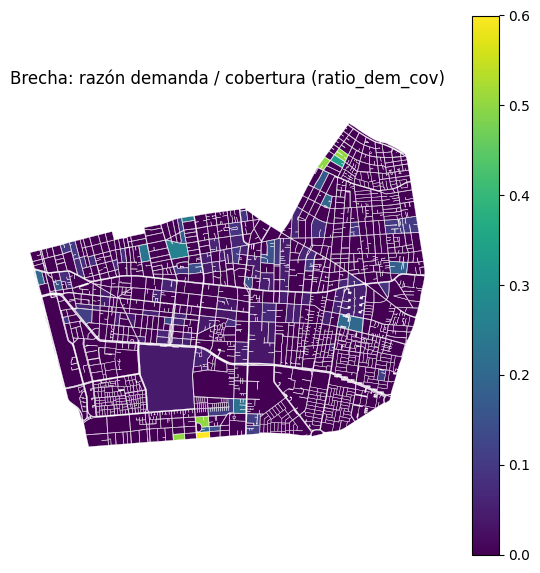

In [ ]:
# =========================================================
# CELDA 8) Diagnóstico: ratio demanda/cobertura
# =========================================================
zonas["ratio_dem_cov"] = zonas["demanda_total"] / np.maximum(zonas["SUM_Peso"], 1e-6)

print(zonas["ratio_dem_cov"].describe())

fig, ax = plt.subplots(1, 1, figsize=(7,7))
zonas.plot(column="ratio_dem_cov", legend=True, ax=ax, linewidth=0.2, edgecolor="white")
ax.set_title("Brecha: razón demanda / cobertura (ratio_dem_cov)")
ax.set_axis_off()
plt.show()


In [ ]:
# =========================================================
# CELDA 9) Optimización p=1: nuevo PRIVADO (isócrona candidata)
#  - define tau, w_new, t_new
#  - elige top N candidatos por beneficio
#  - evalúa mejor candidato por beneficio capturado
# =========================================================
tau   = 3.0
w_new = 1.5
t_new = 18  # minutos nuevo privado (escenario base)

zonas["deficit"]     = np.maximum(0, tau - zonas["SUM_Peso"])
zonas["beneficio_i"] = zonas["demanda_total"] * np.minimum(zonas["deficit"], w_new)

N_cand = min(150, len(zonas))
cand = zonas.sort_values("beneficio_i", ascending=False).head(N_cand).copy()
cand["geometry"] = cand.geometry.representative_point()
cand = cand.set_geometry("geometry")

best_score, best_iso, best_idx = -1, None, None

for k, (i, r) in enumerate(cand.iterrows(), start=1):
    iso = make_isochrone(G, r.geometry, t_new)
    covered = zonas.geometry.intersects(iso)
    score = float(zonas.loc[covered, "beneficio_i"].sum())
    if score > best_score:
        best_score, best_iso, best_idx = score, iso, i
    if k % 25 == 0:
        print(f"Evaluadas {k}/{len(cand)} candidatas... mejor score actual = {best_score:.3f}")

new_site = cand.loc[[best_idx]].copy()
new_buf  = gpd.GeoDataFrame([{"geometry": best_iso}], crs=EPSG_UTM)

covered_new = zonas.geometry.intersects(best_iso)
zonas["SUM_Peso_post"] = zonas["SUM_Peso"] + (w_new * covered_new.astype(int))
zonas["cubierto_actual"] = zonas["SUM_Peso"] >= tau
zonas["cubierto_final"]  = zonas["SUM_Peso_post"] >= tau
zonas["nueva_cobertura"] = (~zonas["cubierto_actual"]) & (zonas["cubierto_final"])
zonas["delta_peso"]      = zonas["SUM_Peso_post"] - zonas["SUM_Peso"]

print("Mejor candidato (índice):", best_idx, "| beneficio capturado:", best_score)
print("Zonas total:", len(zonas))
print("Zonas True (mejoran):", int(zonas["nueva_cobertura"].sum()))
print("Cobertura antes:", zonas["cubierto_actual"].mean(), "| después:", zonas["cubierto_final"].mean())

# coordenadas del punto en lat/lon
new_site_ll = new_site.to_crs(4326).copy()
print("Nuevo privado (lon, lat):", float(new_site_ll.geometry.x), float(new_site_ll.geometry.y))


/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.co

Evaluadas 25/150 candidatas... mejor score actual = 2.000


/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.co

Evaluadas 50/150 candidatas... mejor score actual = 2.000


/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.co

...

/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.co

Evaluadas 125/150 candidatas... mejor score actual = 2.000


/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.co

Evaluadas 150/150 candidatas... mejor score actual = 2.000
Mejor candidato (índice): 14 | beneficio capturado: 2.0
Zonas total: 1347
Zonas True (mejoran): 14
Cobertura antes: 0.9821826280623608 | después: 0.9925760950259837
Nuevo privado (lon, lat): -70.5838897010078 -33.437909529200425


/tmp/ipython-input-3738039.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = gpd.GeoSeries(node_pts, crs=4326).unary_union.convex_hull
/tmp/ipython-input-3774828857.py:47: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Nuevo privado (lon, lat):", float(new_site_ll.geometry.x), float(new_site_ll.geometry.y))


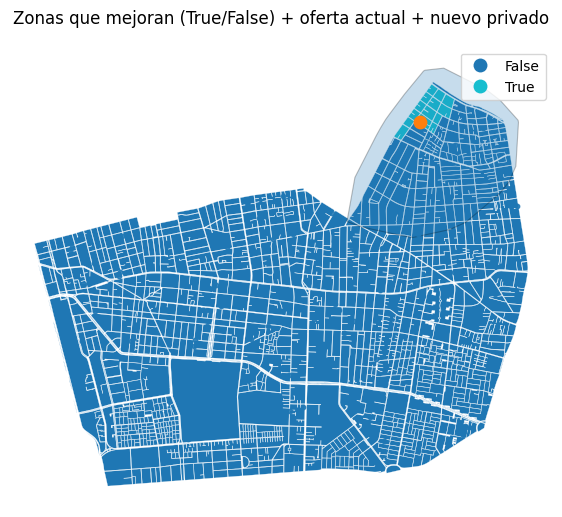

Zonas con delta_peso > 0: 166
Promedio delta_peso: 0.18485523385300667
Máximo delta_peso: 1.5


In [ ]:
# =========================================================
# CELDA 10) Visualización final: True/False + nuevo + área + colegios
# =========================================================
fig, ax = plt.subplots(1, 1, figsize=(7,7))

zonas.assign(flag=zonas["nueva_cobertura"]).plot(
    column="flag", categorical=True, legend=True,
    ax=ax, linewidth=0.2, edgecolor="white"
)

new_buf.plot(ax=ax, alpha=0.25, edgecolor="black", linewidth=0.8)
colegios_f.plot(ax=ax, markersize=10, alpha=0.85)
new_site.plot(ax=ax, markersize=80)

ax.set_title("Zonas que mejoran (True/False) + oferta actual + nuevo privado")
ax.set_axis_off()
plt.show()

print("Zonas con delta_peso > 0:", int((zonas["delta_peso"] > 0).sum()))
print("Promedio delta_peso:", zonas["delta_peso"].mean())
print("Máximo delta_peso:", zonas["delta_peso"].max())


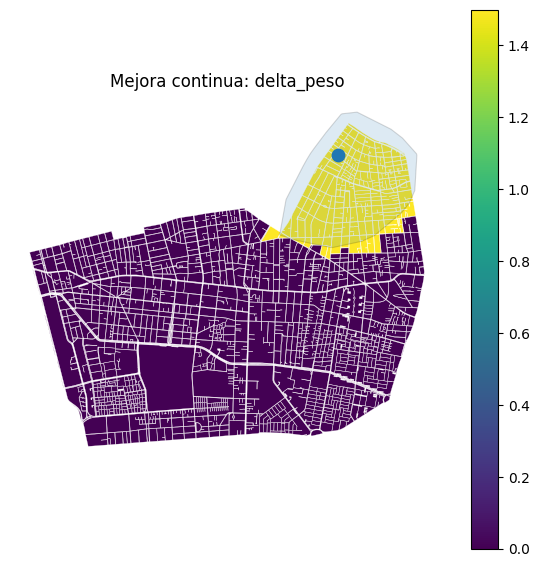

In [ ]:
# =========================================================
# CELDA 11) Visualización: mejora continua (delta_peso)
# =========================================================
fig, ax = plt.subplots(1, 1, figsize=(7,7))
zonas.plot(column="delta_peso", legend=True, ax=ax, linewidth=0.2, edgecolor="white")
new_buf.plot(ax=ax, alpha=0.15, edgecolor="black", linewidth=0.8)
new_site.plot(ax=ax, markersize=80)
ax.set_title("Mejora continua: delta_peso")
ax.set_axis_off()
plt.show()


In [ ]:
print("nueva_cobertura value_counts:")
print(zonas["nueva_cobertura"].value_counts(dropna=False))

print("\nCubierto actual (SUM_Peso >= tau):")
print((zonas["SUM_Peso"] >= tau).value_counts())

print("\nCubierto final (SUM_Peso_post >= tau):")
print((zonas["SUM_Peso_post"] >= tau).value_counts())

print("\nZonas con deficit>0 (SUM_Peso < tau):", int((zonas["SUM_Peso"] < tau).sum()))
print("Zonas tocadas por el nuevo (delta_peso>0):", int((zonas["delta_peso"] > 0).sum()))


nueva_cobertura value_counts:
nueva_cobertura
False    1333
True       14
Name: count, dtype: int64

Cubierto actual (SUM_Peso >= tau):
SUM_Peso
True     1323
False      24
Name: count, dtype: int64

Cubierto final (SUM_Peso_post >= tau):
SUM_Peso_post
True     1337
False      10
Name: count, dtype: int64

Zonas con deficit>0 (SUM_Peso < tau): 24
Zonas tocadas por el nuevo (delta_peso>0): 166
